In [1]:
import glob
import corner
import sep

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import LogFormatterMathtext
from matplotlib import gridspec
import matplotlib.lines as mlines

import pandas as pd
import numpy as np
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.signal import fftconvolve
from scipy.stats import norm
from scipy.integrate import quad
from scipy.integrate import cumulative_trapezoid

from astropy.table import Table, vstack
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.convolution import convolve, Gaussian1DKernel
from astropy.nddata import block_reduce
from astropy.table.notebook_backends import ipydatagrid
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

from photutils.detection import find_peaks
import emcee

from bt_functions import grab_image, add_noise, plot_object, reduce, get_scale_pkpc, get_scale_as

In [2]:
# ---------------------------
# -------- LOAD DATA --------
# ---------------------------
redshift = 7

bluetides_path = '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_*/hlsp_bluetides_jwst_nircam_z{redshift}*_f*w_v1_sim-*.fits'
img_path = '/Volumes/SeagateBack/bluetides/plots'
code_path = '/Volumes/SeagateBack/bluetides/code'

filenames = glob.glob(bluetides_path.format(redshift=redshift))       # finds all files in path with given format 
print("Number of files:",len(filenames))                              # there are 56 files in total for z=7

catalog = Table.read('/Volumes/SeagateBack/bluetides/code/hlsp_bluetides_multi_multi_all_multi_v2_sim.csv')
if 'id' in catalog.colnames:
    catalog.replace_column('id', 1 + np.arange(len(catalog)))
else:
    catalog.add_column(1 + np.arange(len(catalog)), name='id', index=0)

catalog[:10]

Number of files: 56


id,col0,redshift,fileNumber,extensionNumber,stellarMass,BHmass,BHluminosity,haloMass,lum_FUV,flux_jwst.nircam.f090w,radius_jwst.nircam.f090w,flux_jwst.nircam.f115w,radius_jwst.nircam.f115w,flux_jwst.nircam.f150w,radius_jwst.nircam.f150w,flux_jwst.nircam.f200w,radius_jwst.nircam.f200w,flux_jwst.nircam.f277w,radius_jwst.nircam.f277w,flux_jwst.nircam.f356w,radius_jwst.nircam.f356w,flux_jwst.nircam.f410m,radius_jwst.nircam.f410m,flux_jwst.nircam.f444w,radius_jwst.nircam.f444w,flux_jwst.miri.f560w,radius_jwst.miri.f560w,flux_jwst.miri.f770w,radius_jwst.miri.f770w,flux_hst.wfc3.f105w,radius_hst.wfc3.f105w,flux_hst.wfc3.f125w,radius_hst.wfc3.f125w,flux_hst.wfc3.f140w,radius_hst.wfc3.f140w,flux_hst.wfc3.f160w,radius_hst.wfc3.f160w,flux_euclid.nisp.y,radius_euclid.nisp.y,flux_euclid.nisp.j,radius_euclid.nisp.j,flux_euclid.nisp.h,radius_euclid.nisp.h,flux_roman.wfi.f087,radius_roman.wfi.f087,flux_roman.wfi.f106,radius_roman.wfi.f106,flux_roman.wfi.f129,radius_roman.wfi.f129,flux_roman.wfi.f146,radius_roman.wfi.f146,flux_roman.wfi.f158,radius_roman.wfi.f158,flux_roman.wfi.f184,radius_roman.wfi.f184,flux_subaru.hsc.z,radius_subaru.hsc.z,flux_subaru.hsc.y,radius_subaru.hsc.y,flux_vista.vircam.z,radius_vista.vircam.z,flux_vista.vircam.y,radius_vista.vircam.y,flux_vista.vircam.j,radius_vista.vircam.j,flux_vista.vircam.h,radius_vista.vircam.h,flux_vista.vircam.ks,radius_vista.vircam.ks,flux_spitzer.irac.ch1,flux_spitzer.irac.ch2
int64,int64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0,7.0,1,1,62058380000.0,374432960.0,9.854875355041004e+46,1292328500000.0,1.2920170160111174e+29,23.11590576171875,1.2503641843795776,169.21633911132812,1.1419026851654053,186.37940979003906,1.058977723121643,195.3888702392578,0.99473637342453,261.0684814453125,0.893967866897583,470.4862060546875,0.8837507963180542,635.4224243164062,0.8629537224769592,543.959228515625,0.8785976767539978,623.2904052734375,1.012123703956604,682.6275024414062,1.0523561239242554,125.1771011352539,1.2744066715240479,175.79356384277344,1.2591437101364136,183.14561462402344,1.2591437101364136,188.14297485351562,1.2591437101364136,183.15052795410156,1.7575469017028809,221.62730407714844,1.7575469017028809,227.99705505371094,1.6979515552520752,9.006768226623535,1.2672045230865479,129.13966369628906,1.2562328577041626,178.63833618164062,1.233996868133545,171.67251586914062,1.233996868133545,189.06185913085938,1.2227272987365723,192.5867462158203,1.233996868133545,13.57265567779541,2.1514832973480225,81.3726806640625,2.182002305984497,48.2589225769043,2.300032377243042,212.34750366210938,2.300032377243042,218.61846923828125,2.2417943477630615,241.94602966308594,2.2417943477630615,243.62803649902344,2.2417943477630615,503.7591247558594,553.727783203125
2,1,7.0,1,2,129293664000.0,365300220.0,9.614507498709602e+46,8704022300000.0,6.276021859962179e+29,104.62671661376953,1.5874279737472534,813.4927978515625,1.5317360162734985,980.5615234375,1.4836066961288452,1121.8316650390625,1.4498753547668457,1516.3748779296875,1.3743971586227417,2676.136962890625,1.3842731714248657,3508.948974609375,1.4421098232269287,3085.17578125,1.3842731714248657,3377.263916015625,1.4975289106369019,3822.9365234375,1.4882562160491943,595.3988037109375,1.5608230829238892,861.0501708984375,1.5608230829238892,931.8605346679688,1.5608230829238892,1000.8505859375,1.5608230829238892,1080.4014892578125,2.313918113708496,1379.1951904296875,2.313918113708496,1548.9696044921875,2.357996702194214,37.4470329284668,1.5872795581

In [3]:
# --------------------------------------------------------------
# --- REPLACE LUM FUV COLUMN IN ALL TABLES USING NEW CATALOG ---
# --------------------------------------------------------------
f150w_Table = Table.read(f'{code_path}/sep_table_f150w.ecsv')

lum_map = {row['id']: row['lum_FUV'] for row in catalog}

def replace_luminosity(table, lum_map):
    table_ids = table['id'].astype(int)
    table['lumFUV'] = [lum_map.get(i, np.nan) for i in table_ids]
    return table

f150w_Table = replace_luminosity(f150w_Table, lum_map)

# ----------------------------------------
# --- ADD DISTANCE COLS IN PKPC AND AS ---
# ----------------------------------------

unique_ids = np.unique(f150w_Table['id'])
scale_pkpc = {}
scale_as = {}

for id in unique_ids:
    try:
        scale_pkpc[id] = get_scale_pkpc(id, filter='f150w', redshift=7, catalog=catalog, filenames=filenames)
        scale_as[id] = get_scale_as(id, filter='f150w', redshift=7, catalog=catalog, filenames=filenames)
    except:
        print(f"Could not load scale for id={id}")


# Map ID → scale, then broadcast
f150w_Table['distance_pkpc'] = [
    scale_pkpc[row['id']] * row['distances'] 
    for row in f150w_Table
]
f150w_Table['distance_as'] = [
    scale_as[row['id']] * row['distances'] 
    for row in f150w_Table
]
f150w_Table


id,haloMass,bhMass,stellarMass,lumFUV,convolution,distances,flux_ratio,area_1,area_2,has_psf,distance_pkpc,distance_as
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,float64
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.0,5.8341918239615005,0.5927456669607006,50.0,60.0,False,0.4849058196688117,0.09042997327140326
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.5,11.315334820295579,0.2710036965865495,48.0,115.0,False,0.9404681696147605,0.17538768971458146
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,1.0,4.458249248190907,0.47129277006608244,85.0,176.0,False,0.37054506797377823,0.06910286334695906
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,2.0,0.0,0.0,0.0,0.0,False,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,5.0,0.0,0.0,0.0,0.0,False,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.0,0.0,0.0,0.0,0.0,True,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,0.5,0.0,0.0,0.0,0.0,True,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,1.0,0.0,0.0,0.0,0.0,True,0.0,0.0
1,1292328500000.0,374432960.0,62058380000.0,1.2920170160111174e+29,2.0,0.0,0.0,0.0,0.0,True,0.0,0.0


In [4]:
# Create a set of known pair indices to define ground truth
# By-eye pairs
pair_indices = {
    2, 8, 13, 17, 19, 25, 27, 33, 37, 38, 41, 57, 62, 64, 72, 76, 79, 87, 88, 90,
    93, 94, 95, 97, 98, 99, 105, 107, 109, 112, 117, 128, 136, 147, 167, 171, 184,
    191, 199, 201, 204, 209, 217, 228, 233, 285, 311, 326, 330, 332, 344, 357, 364,
    385, 388, 396, 402, 405, 407, 433, 456, 469, 472, 494, 504, 511, 523, 530, 556,
    559, 568, 616, 617, 625, 640, 641, 650, 657, 664, 669, 678, 681, 683, 727, 729,
    745, 749, 760, 773, 794, 800, 802, 814, 821, 830, 845, 850, 852, 870, 879, 903,
    915, 919, 954, 987, 997
}

# Create arrays for pairs and non-pairs under 1000
all_indices = set(range(1000))
non_pairs = sorted(all_indices - pair_indices)
print(len(pair_indices)/1000)
pairs = sorted(pair_indices)

0.106


/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_3016/1020219025.py:155: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  uvlf = ax.errorbar(


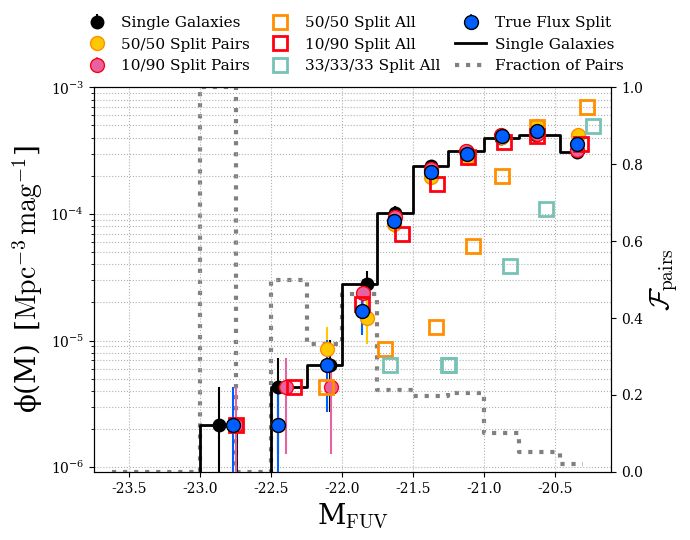

In [5]:
# ============================================================ #
#           GLOBAL FONT SETTINGS (Math Font Everywhere)        #
# ============================================================ #

plt.rcParams['mathtext.fontset'] = 'cm'        # Computer Modern math font
plt.rcParams['font.family'] = 'serif'          # Use serif for all non-math text
plt.rcParams['font.serif'] = ['CMU Serif', 'DejaVu Serif']

plt.rcParams['axes.unicode_minus'] = False     # Proper minus signs
plt.rcParams['mathtext.default'] = 'regular'   # Consistent regular math font

# ================================================ #
#   FUV Luminosity Function + Fraction of Pairs    #
# ================================================ #

df = f150w_Table.copy()
df['is_pair'] = np.isin(df['id'], pairs) & (df['has_psf'] == False) & (df['convolution'] == 0.0)

# ----- Select GT from Catalog -----
mask_nopsf = ((df['has_psf'] == False) & (df['convolution'] == 0.0))
lum_FUV = df[mask_nopsf]['lumFUV']

# ----- Split Luminosity for Pair Galaxies -----
lum_sets = {
    'single': [], 
    '5050_pairs': [], '1090_pairs': [],
    '5050_all': [], '1090_all': [], 
    '33_all': [],
    'split': [],
    }

for row in df[mask_nopsf]:

    lum_sets['single'].append(row['lumFUV'])

    # SPLITTING WHOLE SAMPLE    
    lum_sets['5050_all'].extend([row['lumFUV'] * 0.5, row['lumFUV'] * 0.5]) # 50/50 flux split
    lum_sets['1090_all'].extend([row['lumFUV'] * 0.1, row['lumFUV'] * 0.9]) # 10/90 flux split
    lum_sets['33_all'].extend([row['lumFUV'] * 0.33, row['lumFUV'] * 0.33, row['lumFUV'] * 0.33]) # 33/33/33 flux split

    # SPLITTING ONLY PAIRS
    if row['is_pair']:
        lum_sets['split'].extend([
            row['lumFUV'] * row['flux_ratio'],
            row['lumFUV'] * (1 - row['flux_ratio'])
        ])
        lum_sets['5050_pairs'].extend([row['lumFUV'] * 0.5, row['lumFUV'] * 0.5])
        lum_sets['1090_pairs'].extend([row['lumFUV'] * 0.1, row['lumFUV'] * 0.9])

    else:
        lum_sets['split'].append(row['lumFUV'])
        lum_sets['5050_pairs'].append(row['lumFUV'])
        lum_sets['1090_pairs'].append(row['lumFUV'])

# ----- Convert luminosity to magnitude -----
M_FUV = {}
for key, lum_values in lum_sets.items():
    lum_log = np.log10(lum_values)
    M_FUV[key] = 51.63 - 2.5 * lum_log

# ----- Volume of sample ----- 
len_sample = np.sum(mask_nopsf)
len_catalog = len(catalog)
h = 0.7
L_box = 400 / h
V_box = L_box**3
V_eff = V_box * (len_sample / len_catalog)

# ----- Construct bins -----
bin_width = 0.25
bin_phase = 0

M_min = -23.75
M_max = -20.25
mag_cutoff = -20.1

bins_regular = np.arange(M_min, M_max, bin_width)  # magnitude bins width 0.25
bins_M = np.append(bins_regular, mag_cutoff)
bin_centers_M = 0.5 * (bins_M[:-1] + bins_M[1:])
bin_width_M = bins_M[1] - bins_M[0]

# ----- Compute bin median magnitudes -----
median_key = 'single'   # to compute medians consistently

# ----- Calculate UVLF -----
phi_M = {}
phi_err_M = {}

labels = {
    'single': 'Single Galaxies', 'split': 'True Flux Split',
    '5050_all': '50/50 Split All', '1090_all': '10/90 Split All', '33_all': '33/33/33 Split All',
    '5050_pairs': '50/50 Split Pairs', '1090_pairs': '10/90 Split Pairs'
}
mfc = {
    'single': 'k', 'split': '#005EFF',
    '5050_all':'None',  '1090_all': 'None', '33_all': 'None',
    '5050_pairs': '#FFC800', '1090_pairs': '#E663A2',
}
mec = {
    'single': 'None', 'split': 'k',
    '5050_all': "#FF8E00", '1090_all': "#FF0011", '33_all': '#77C2B5',
    '5050_pairs': "#FF8E00", '1090_pairs': "#FF0011"
}
markers = {
    'single': 'o', 'split': 'o',
    '5050_all': 's', '1090_all': 's', '33_all': 's',
    '5050_pairs': "o", '1090_pairs': "o"
}
linestyles = {
    'single': '-', 'split': '-', 
    '5050_all': '--', '1090_all': '--'
    }
linewidths = {
    'single': 2, 'split': 1, 
    '5050_all': 2, '1090_all': 2, '33_all': 2,
    '5050_pairs': 1, '1090_pairs': 1
    }

# ----- Fraction of pairs -----
mask_pairs = df[mask_nopsf]['is_pair']
M_single = M_FUV['single']
fraction_pairs = []

for i in range(len(bins_M)-1):
    bin_mask = (M_single >= bins_M[i]) & (M_single < bins_M[i+1])
    if np.sum(bin_mask) > 0:
        fraction_pairs.append(np.mean(mask_pairs[bin_mask]))
    else:
        fraction_pairs.append(0.0)

# ----- Plot UVLF + Pair Fractions -----
fig, ax = plt.subplots(figsize=(7, 5.5))

bin_widths = np.diff(bins_M)

legend_handles = []
for key in lum_sets.keys():
    bin_medians = []
    M_vals = M_FUV[key]

    for i in range(len(bins_M)-1):
        mask = (M_vals >= bins_M[i]) & (M_vals < bins_M[i+1])
        if np.any(mask):
            bin_medians.append(np.median(M_vals[mask]))
        else:
            bin_medians.append(np.nan)

    N_M, _ = np.histogram(M_FUV[key], bins=bins_M)
    phi_M[key] = N_M / (V_eff * bin_widths)
    phi_err_M[key] = np.sqrt(N_M) / (V_eff * bin_widths)

    if key == 'split':
        split_bin_medians = np.array(bin_medians)

    uvlf = ax.errorbar(
        bin_medians, phi_M[key], yerr=phi_err_M[key], label=labels[key],
        fmt='o', color=mfc[key], markeredgecolor=mec[key], marker=markers[key],
        markeredgewidth=linewidths[key], alpha=1, markersize=10, zorder=5
    )
    legend_handles.append(uvlf)
    
# -------------------- SAVE SPLIT UVLF FOR REUSE -------------------- #

UVLF_SPLIT = {
    'bin_centers': bin_centers_M,
    'M_median': split_bin_medians,   # from key == 'split'
    'phi': phi_M['split'],
    'phi_err': phi_err_M['split'],
    'bins': bins_M,
    'bin_centers': bin_centers_M,
    'V_eff': V_eff
}

UVLF_5050 = {
    'bin_centers': bin_centers_M,
    'M_median': split_bin_medians,   # from key == 'split'
    'phi': phi_M['5050_pairs'],
    'phi_err': phi_err_M['5050_pairs'],
    'bins': bins_M,
    'bin_centers': bin_centers_M,
    'V_eff': V_eff
}

single_ladies, = ax.step(
    bin_centers_M, phi_M['single'], where='mid',
    color=mfc['single'], linestyle=linestyles['single'], 
    linewidth=linewidths['single'], zorder=2,
    label=labels['single']
)
legend_handles.append(single_ladies)


# math-font ticks
ax.yaxis.set_major_formatter(LogFormatterMathtext())
ax.set_yscale('log')
ax.set_xlabel(r'$M_{\mathrm{FUV}}$', fontsize=20)
ax.set_ylabel(r'$\phi(M)\;\;[\mathrm{Mpc^{-3}\,mag^{-1}}]$', fontsize=20)
ax.set_xlim(M_min, mag_cutoff)
ax.grid(True, which='both', ls=':')
ax.patch.set_alpha(0.0) # makes background transparent

# ----- Pair fraction axis -----
ax2 = ax.twinx()
ax2.set_zorder(ax.get_zorder() - 1) # plots axis 2 first

pair_frac, = ax2.step(
    bin_centers_M, fraction_pairs, ':', where='mid',
    color='grey', label='Fraction of Pairs', linewidth=3, zorder=1
)
legend_handles.append(pair_frac)

ax2.set_ylim(0, 1)
ax2.set_ylabel(r'$\mathcal{F}_{\mathrm{pairs}}$', fontsize=20)

# legend
leg = ax.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=3,
    fontsize=11,
    handlelength=2,
    handletextpad=0.6,
    columnspacing=1.0,
    markerscale=1,
    frameon=False
)

# Ensure right-axis tick labels use math font too (auto)
plt.tight_layout()
plt.show()

#### Schechter function and sampling function

In [6]:
def schechter(M, phi_star, M_star, alpha):
    """
    Calculates a Schechter function in magnitude-space

    Parameters
    ----------
    M : array or float
        binned Magnitude
    phi_star : float, 
        normalization
    M_star : float, 
        "knee" - transition from power law to exponential cutoff
    alpha : float
        faint-end slope

    Return value
    ------------
    Phi(M) : Schechter function
    """
    x = 10**(0.4 * (M_star - M))
    return 0.4 * np.log(10) * phi_star * x**(alpha + 1) * np.exp(-x)


def plot_sample(
    M_samples,
    M_star,
    phi_star,
    alpha,
    M_bright,
    M_faint,
    volume,
    plot_input=True,
    label='Sample',
    ax=None
):
    """
    Plot sampled magnitudes as a UV luminosity function.
    """

    # use provided axis or current axis
    if ax is None:
        ax = plt.gca()

    bins = np.linspace(M_bright, M_faint, 30)
    bin_widths = np.diff(bins)
    centers = 0.5 * (bins[:-1] + bins[1:])

    counts, edges = np.histogram(M_samples, bins=bins)
    phi = counts / volume / bin_widths
    mask = phi > 0

    # Plot input Schechter
    if plot_input:
        M_plot = np.linspace(M_bright, M_faint, 500)
        phi_plot = schechter(M_plot, phi_star, M_star, alpha)

        ax.plot(
            M_plot,
            phi_plot,
            linestyle='--',
            label='Input Schechter'
        )

    # Plot sampled LF
    ax.step(
        centers[mask],
        phi[mask],
        where='mid',
        label=label
    )

    # Formatting
    ax.set_xlabel("Magnitude")
    ax.set_ylabel(r"$\phi(M)$ [Mpc$^{-3}$ mag$^{-1}$]")
    ax.set_yscale('log')
    ax.set_ylim(1e-8, 1e-1)


def sample_from_schechter(M_star, phi_star, alpha,
                         M_faint, M_bright, volume,
                         plot_results=True, plot_input=True,
                         verbose=True):
    """
    Rejection sampling from a Schechter luminosity function.

    Parameters
    ----------
    n_expected : int
        Number of galaxies to sample
    M_star, phi_star, alpha : float
        Schechter parameters
    M_faint : float
        Faint-end magnitude limit (where phi_max is defined)
    M_bright : float
        Bright-end magnitude limit
    volume : float
        Survey volume (Mpc^3)
    """

    # --- 1. True expected number of galaxies ---
    integral, _ = quad(
        lambda m: schechter(m, phi_star, M_star, alpha),
        M_bright, M_faint
    )
    N_true = integral * volume

    # --- 2. Find robust maximum for rejection sampling ---
    M_grid = np.linspace(M_bright, M_faint, 1000)
    phi_vals = schechter(M_grid, phi_star, M_star, alpha)
    phi_max = np.max(phi_vals)

    # --- 3. Rejection sampling (shape only) ---
    kept = []
    n_kept = 0
    n_total = 0

    n_draw = int(N_true)

    # draw until expected # of galaxies is reached
    while n_kept < n_draw:
        M_trial = np.random.uniform(M_bright, M_faint)              # draw randomly from uniform magnitude distribution
        phi_trial = schechter(M_trial, phi_star, M_star, alpha)     # corresponding phi value

        # random chance of being kept
        if np.random.rand() < (phi_trial / phi_max):
            kept.append(M_trial)
            n_kept += 1

        n_total += 1

    kept = np.array(kept)

    if verbose:
        print(f"True expected number in volume: {N_true:.1f}")
        print("number of galaxies drawn:", n_draw)
        print(f"Acceptance fraction: {n_kept / n_total:.3f}")

    # --- 5. Plot comparison ---
    if plot_results:
        plot_sample(kept, M_star, phi_star, alpha,
                M_bright, M_faint, volume, plot_input)

    return kept

True expected number in volume: 602972.4
number of galaxies drawn: 602972
Acceptance fraction: 0.106


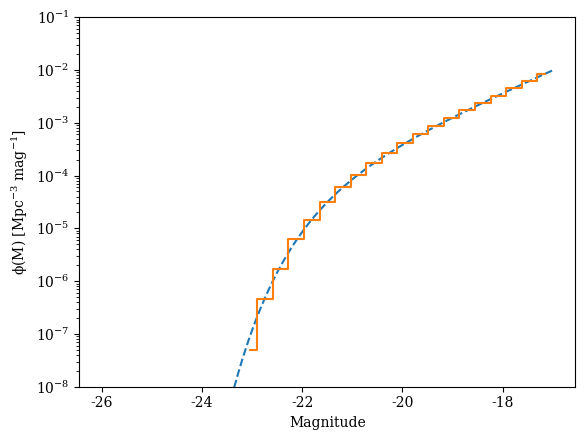

In [7]:
# --- Example parameters (z ~ 6.8) ---
phi_star_bouwens = 0.19e-3
M_star_bouwens = -21.15
alpha_bouwens = -2.06

samples = sample_from_schechter(
    M_star=M_star_bouwens,
    phi_star=phi_star_bouwens,
    alpha=alpha_bouwens,
    M_faint=-17,
    M_bright=-26,
    volume=400**3,
    plot_results=True,
    # plot_input=False
)

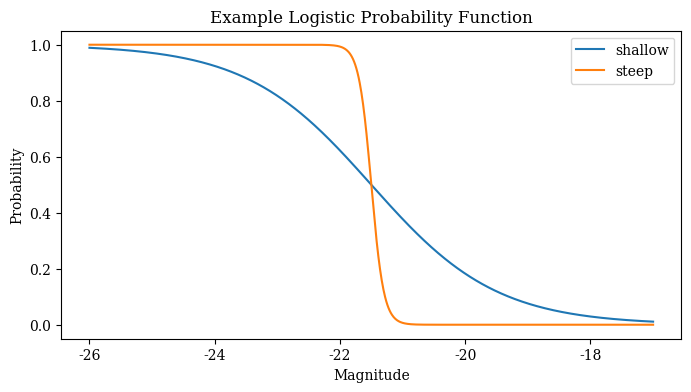

In [8]:
def logistic(M, M0=-21.5, k=1.0):
    """
    Logistic probability that a galaxy splits into two.

    Parameters
    ----------
    M : float or array
        Magnitude
    M0 : float
        midpoint (P=0.5)
    k : float
        Controls steepness (smaller = sharper transition)

    Returns
    -------
    P : float or array
        Probability of splitting
    """
    return 1 / (1 + np.exp((M - M0) / k))


# Visualize Probability Function:
M_grid = np.linspace(-26, -17, 1000)
split_probability = logistic(M_grid)
split_probability_steep = logistic(M_grid, M0=-21.5, k=0.1)

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(M_grid, split_probability, label='shallow')
ax.plot(M_grid, split_probability_steep, label='steep')

ax.set_xlabel('Magnitude')
ax.set_ylabel('Probability')
ax.set_title('Example Logistic Probability Function')
ax.legend()

True expected number in volume: 602972.4
number of galaxies drawn: 602972
Acceptance fraction: 0.106


Text(0, 0.5, 'Splitting Probability')

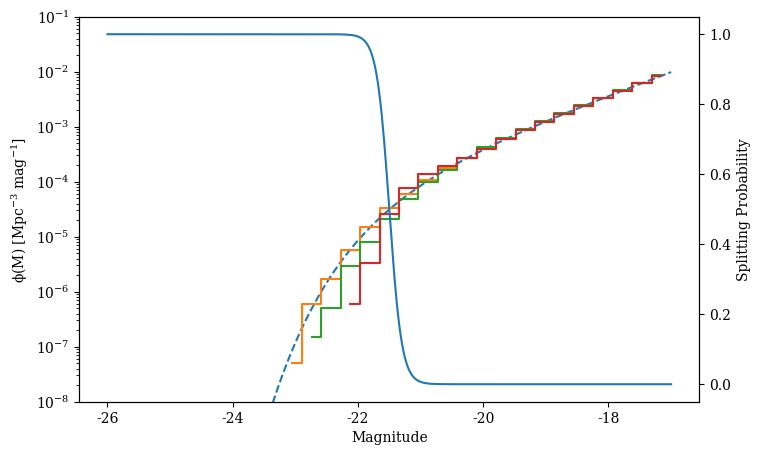

In [9]:
def apply_splitting(M_samples, M0=-21.5, k=1.0):
    M_samples = np.asarray(M_samples, dtype=float)

    # Compute split probabilities for all samples
    P_split = logistic(M_samples, M0, k)

    # Decide which galaxies split
    rand = np.random.rand(M_samples.size)
    split_mask = rand < P_split

    # Count how many will split
    n_split = np.sum(split_mask)

    # Allocate output array (splits produce +1 extra entry each)
    new_size = M_samples.size + n_split
    new_M = np.empty(new_size, dtype=M_samples.dtype)

    # Fill values
    idx = 0
    for i in range(M_samples.size):
        if split_mask[i]:
            M_new = M_samples[i] + 0.75
            new_M[idx] = M_new
            new_M[idx + 1] = M_new
            idx += 2
        else:
            new_M[idx] = M_samples[i]
            idx += 1

    return new_M

# 1. sample from Schechter to get M_samples
# 2. apply splitting function to get new magnitude array
# 3. fit for M0 and k such that splitting mimics bluetides expmts

# --- Example parameters (z ~ 6.8) Bouwens+23 ---
fig, ax = plt.subplots(figsize=(8,5))

# Schechter function params
phi_star_bouwens = 0.19e-3
M_star_bouwens = -21.15
alpha_bouwens = -2.06

# Define magnitude grid
M_faint = -17
M_bright = -26
volume = 400**3

bins = np.linspace(M_bright, M_faint, 500)
# bin_width = bins[1] - bins[0]
# centers = 0.5 * (bins[:-1] + bins[1:])

# Sample from Bouwens+23:
samples = sample_from_schechter(
    M_star=M_star_bouwens,
    phi_star=phi_star_bouwens,
    alpha=alpha_bouwens,
    M_faint=M_faint,
    M_bright=M_bright,
    volume=volume,
    plot_results=False
)

plot_sample(
    samples, 
    M_star_bouwens, 
    phi_star_bouwens, 
    alpha_bouwens,
    M_bright, 
    M_faint, 
    volume,
    plot_input=True
    )

# Apply splitting function:
split_samples = apply_splitting(samples)

plot_sample(
    split_samples, 
    M_star_bouwens, 
    phi_star_bouwens, 
    alpha_bouwens,
    M_bright, 
    M_faint, 
    volume,
    label='Split Sample (k=1)',
    plot_input=False
    )


split_samples = apply_splitting(samples, M0=-21.5, k=0.1)

plot_sample(
    split_samples, 
    M_star_bouwens, 
    phi_star_bouwens, 
    alpha_bouwens,
    M_bright, 
    M_faint, 
    volume,
    label='Split Sample (k=0.1)',
    plot_input=False
    )

ax2 = ax.twinx()
ax2.plot(bins, logistic(bins, M0=-21.5, k=0.1))
ax2.set_ylabel('Splitting Probability')

ultimately want to run emcee to fit all params - schecter + logistic <br>
invert the process - start from a schechter function and start adding thing together (group things) <br>
accuracy of splitting as a function of volume <br>

dots with poisson errorbars <br>
show fractional change (not in log) <br>
flux ratio needs to depend on magnitude bin <br>
make a model that combines all parameters <br>
plot split frac as line, add poisson error <br>

## Fitting Split Function With Emcee

In [10]:
def log_schechter(M, M_star, log10_phi_star, alpha): 
    """ 
    Returns log10(phi) safely. 
    """ 
    ln10 = np.log(10) # term = 10^{-0.4(M - M*)} 
    log10_term = -0.4 * (M - M_star) 
    term = 10**log10_term # log φ in natural log 
    log_phi = ( 
        np.log(0.4 * ln10) 
        + log10_phi_star * ln10 
        + (alpha + 1) * np.log(term) 
        - term 
        ) 
    
    return log_phi / ln10 # convert to log10


def bin_sample(M_samples, bins, volume):
    """ 
    bin magnitudes (sampled from schechter)
    computes UVLF from binning
    """
    hist, edges = np.histogram(M_samples, bins=bins)
    phi = hist / volume / np.diff(edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, phi, hist


def equal_count_bins(M_samples, n_bins):
    """
    Create bins so each bin has ~equal number of objects.
    Returns bin edges.
    Can be plugged into bin_sample for bins
    """
    sorted_M = np.sort(M_samples)

    # split into equal-sized chunks
    edges = np.quantile(sorted_M, np.linspace(0, 1, n_bins + 1))

    return edges


def phase_shifted_bins(M_bright, M_faint, n_bins, phase=0.0):
    """
    Uniform-width bins with optional phase shift.
    phase is in units of bin widths.
    """
    width = (M_faint - M_bright) / n_bins

    edges = np.arange(
        M_bright + phase * width,
        M_faint + width,
        width
    )

    return edges

In [ ]:
# Define Priors, Likelihood, and Posterior:
def log_prior(theta):
    M_star, log10_phi_star, alpha = theta

    if -24 < M_star < -18 and -5 < log10_phi_star < -1 and -3 < alpha < -1:
        return 0.0
    return -np.inf

def log_likelihood(theta, centers, log_phi_data, sigma_log):
    M_star, log10_phi_star, alpha = theta

    log_phi_model = log_schechter(centers, M_star, log10_phi_star, alpha)

    return -0.5 * np.sum(((log_phi_data - log_phi_model) / sigma_log)**2)

def log_probability(theta, centers, log_phi_data, sigma_log):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, centers, log_phi_data, sigma_log)

def fit_schechter_from_binning(M_samples, bins, volume, plot_fit=True, ax_main=None, ax_resid=None, verbose=True):
    
    # --- Bin Sample ---
    centers, phi_data, counts = bin_sample(M_samples, bins, volume)

    mask = counts > 0
    centers = centers[mask]
    phi_data = phi_data[mask]

    phi_err = np.sqrt(counts[mask]) / volume / np.diff(bins)[mask]

    log_phi_data = np.log10(phi_data)
    sigma_log = phi_err / (phi_data * np.log(10))

    # --- Run Emcee --- 
    ndim = 3
    nwalkers = 32

    initial = np.array([-21.0, -3.5, -2.0])
    pos = initial + 1e-1 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_probability,
        args=(centers, log_phi_data, sigma_log)
    )

    sampler.run_mcmc(pos, 3000, progress=True)

    samples = sampler.get_chain(discard=1000, thin=10, flat=True)

    # --- Fitting Results ---
    M_star_fit = np.median(samples[:, 0])
    log10_phi_star_fit = np.median(samples[:, 1])
    alpha_fit = np.median(samples[:, 2])

    phi_star_fit = 10**log10_phi_star_fit

    if verbose:
        print("Fit results:")
        print("M* =", M_star_fit)
        print("phi* =", phi_star_fit)
        print("alpha =", alpha_fit)

    if plot_fit == True:
        # --- Plot Results with Residuals ---
        if ax_main is None or ax_resid is None:
            # Generate axes if none are given
            fig, (ax_main, ax_resid) = plt.subplots(
                2, 1, figsize=(7,7), sharex=True,
                gridspec_kw={
                    'height_ratios': [3,1],
                    'hspace': 0
                }
        )
            
        fit_text = (
            f"M* = {M_star_fit:.3f}\n"
            f"phi* = {phi_star_fit:.3e}\n"
            f"alpha = {alpha_fit:.3f}"
        )

        # fine magnitude grid for computing model
        phi_grid = np.linspace(min(M_samples), max(M_samples), 500)
        phi_model_grid = schechter(phi_grid, phi_star_fit, M_star_fit, alpha_fit)

        # model evaluated at bin centers
        phi_model_centers = schechter(centers, phi_star_fit, M_star_fit, alpha_fit)

        # residuals in log space
        residuals = np.log10(phi_data) - np.log10(phi_model_centers)

        # errorbars in log space
        residual_err = sigma_log

        # --- TOP PANEL OF FIGURE ---

        # Xerr = bin widths
        xerr = np.array([
            centers - bins[:-1][mask],   # left widths
            bins[1:][mask] - centers     # right widths
        ])

        ax_main.errorbar(centers, phi_data, xerr=xerr, yerr=phi_err, fmt='o', color='red', label='Split UVLF', zorder=0)
        ax_main.plot(phi_grid, phi_model_grid, color='purple', lw=2, label='Best-fit Schechter', zorder=1)

        # add fit params as text in lower-right corner
        ax_main.text(
            0.98, 0.02, fit_text, transform=ax_main.transAxes,
            fontsize=10, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(
                boxstyle='round',
                facecolor='white',
                alpha=0.8
            )
        )
        ax_main.set_yscale('log')
        ax_main.set_ylabel(r'$\phi(M)$')
        ax_main.legend()

        # --- RESIDUAL PANEL OF FIGURE ---
        
        ax_resid.errorbar( centers, residuals, yerr=residual_err, fmt='o', color='black')
        ax_resid.axhline(0, color='gray', linestyle='--')

        ax_resid.set_xlabel('M')
        ax_resid.set_ylabel(r'$\Delta \log_{10}\phi$')

    return sampler, samples

### Workflow

1) define "true" Schechter: phi(M_true, phi_true, alpha_true)
2) sample from Phi_true -> M_samples
3) apply splitting (M0, k) -> M_split
4) bin and fit M_split for Schechter params
5) emcee reduces chi^2

### Grouping
- make sure total flux is conserved within some tolerance

Convolve with something bell shaped

You must install the tqdm library to use progress indicators with emcee


True expected number in volume: 205358.9
number of galaxies drawn: 205358
Acceptance fraction: 0.149
Fit results:
M* = -20.811194970871775
phi* = 0.0003318346314646873
alpha = -1.9947338285706864


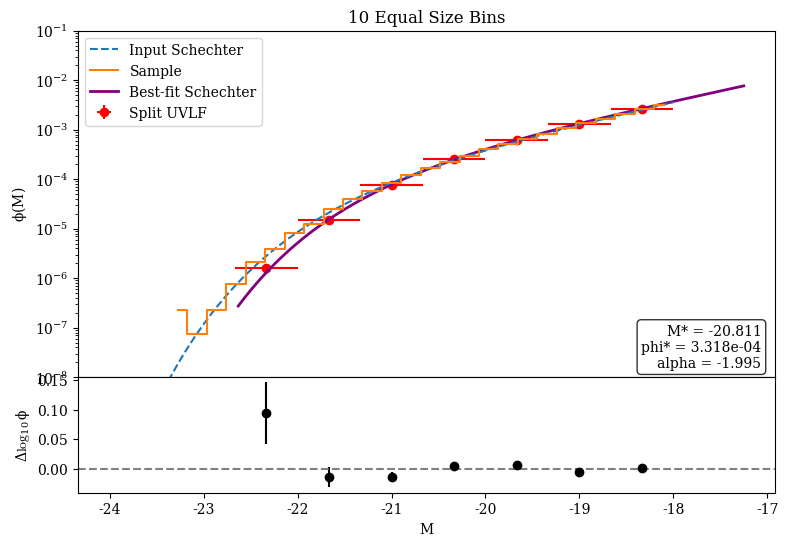

You must install the tqdm library to use progress indicators with emcee


Fit results:
M* = -20.758471140608762
phi* = 0.00035120752400486795
alpha = -1.9869472774051409


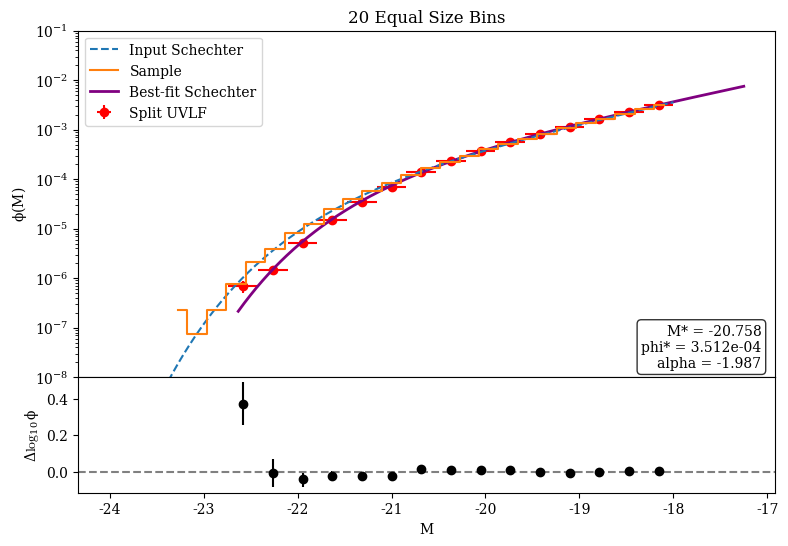

You must install the tqdm library to use progress indicators with emcee


Fit results:
M* = -20.752749448449876
phi* = 0.000353093498711189
alpha = -1.9861602918200216


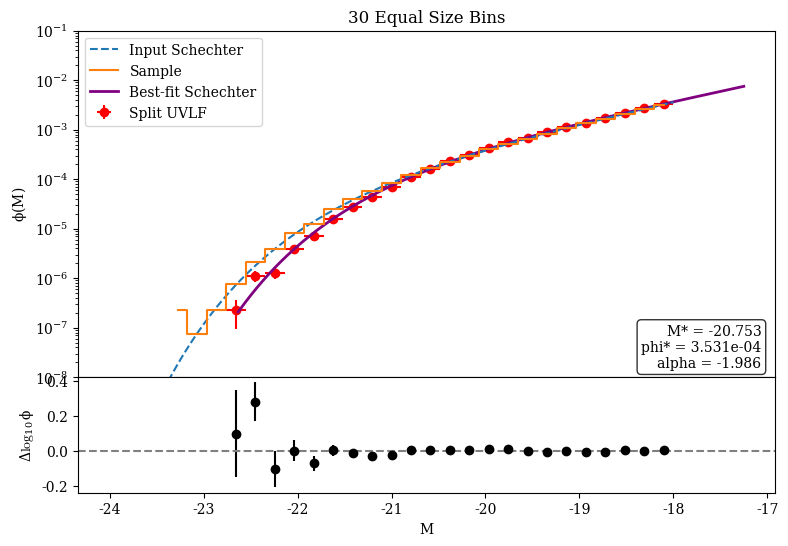

You must install the tqdm library to use progress indicators with emcee


Fit results:
M* = -20.472040710131104
phi* = 0.0006027466061468835
alpha = -1.8165253154766936


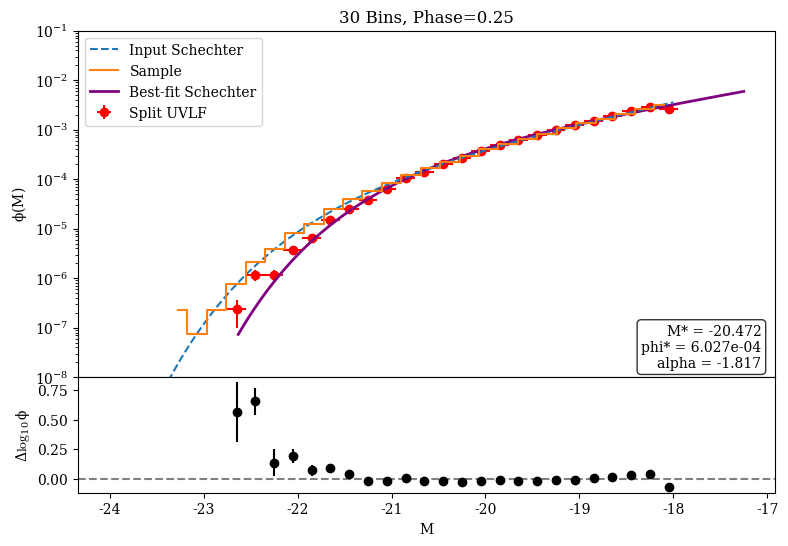

You must install the tqdm library to use progress indicators with emcee


Fit results:
M* = -20.288102930586305
phi* = 0.0008484966268362016
alpha = -1.684605586456514


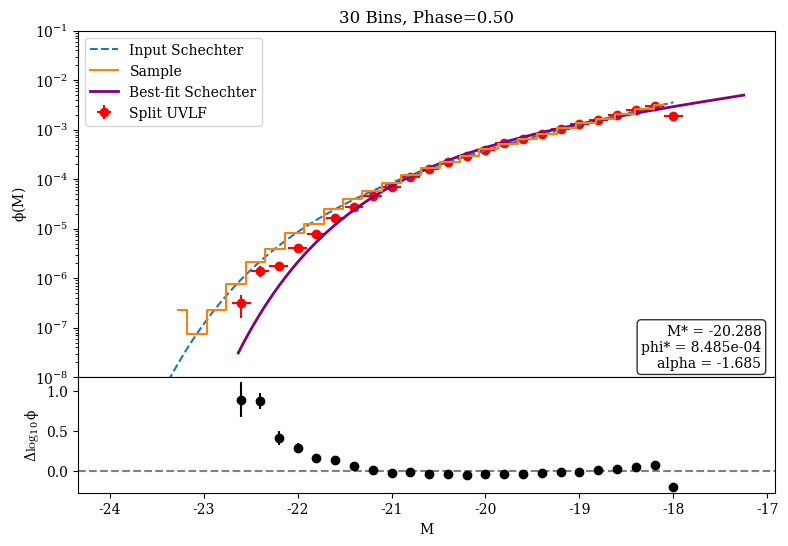

You must install the tqdm library to use progress indicators with emcee


Fit results:
M* = -20.040119493648774
phi* = 0.002278127037591327
alpha = -1.0000970670662424


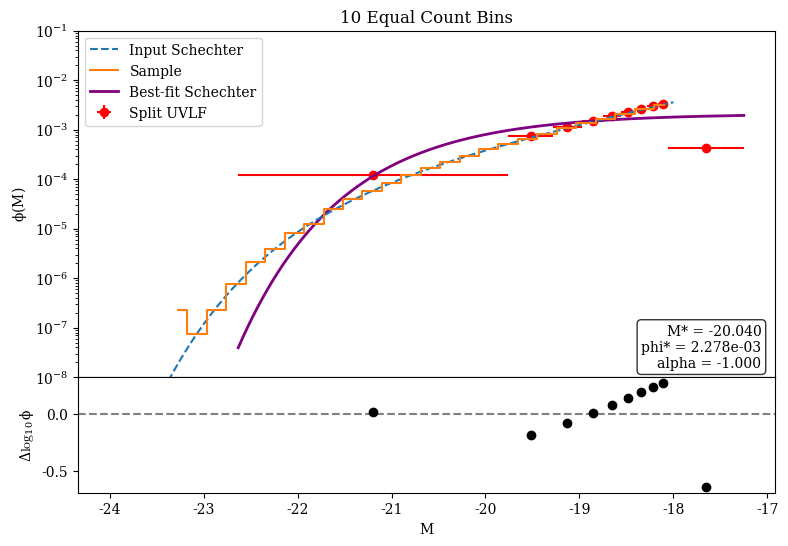

You must install the tqdm library to use progress indicators with emcee


Fit results:
M* = -20.23981083028604
phi* = 0.0015545707830663111
alpha = -1.2579521414069044


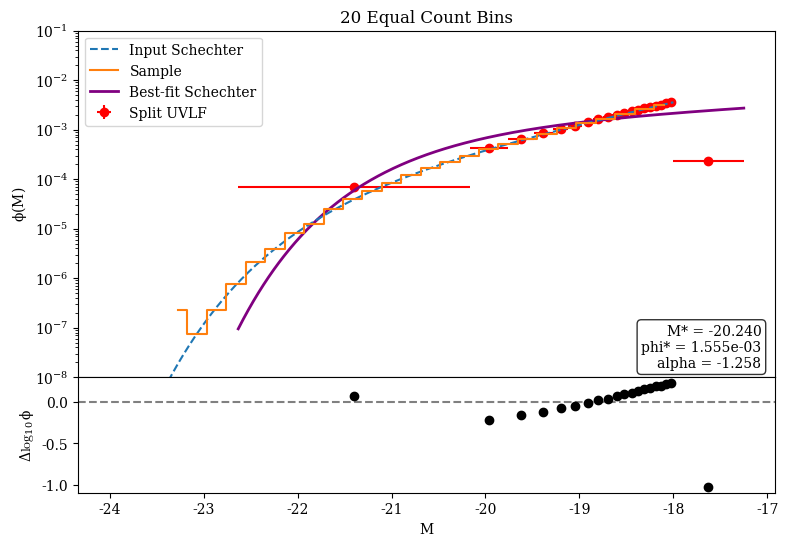

In [12]:
schechter_params_true = (-21.15, 0.19e-3, -2.06)

M_faint = -18 
M_bright = -24 
volume = 400**3

# Sample once
M_samples = sample_from_schechter(
    *schechter_params_true,
    M_faint=M_faint,
    M_bright=M_bright,
    volume=volume,
    plot_results=False
)
# make 1000 samples once, save to disk 

M_split = apply_splitting(M_samples, M0=-21.5, k=1.0)

bins_list = [
    np.linspace(M_bright, M_faint, 10),                     # small # of bins
    np.linspace(M_bright, M_faint, 20),                     # med # of bins
    np.linspace(M_bright, M_faint, 30),                     # large # of bins
    phase_shifted_bins(M_bright, M_faint, 30, phase=0.25),  # phase shift 0.25 mag
    phase_shifted_bins(M_bright, M_faint, 30, phase=0.5),   # phase shift 0.5 mag
    equal_count_bins(M_split, 10),                          # equal counts, small # of bins
    equal_count_bins(M_split, 20),                          # equal counts, med # of bins
]

bin_names = [
    '10 Equal Size Bins',
    '20 Equal Size Bins',
    '30 Equal Size Bins',
    '30 Bins, Phase=0.25',
    '30 Bins, Phase=0.50',
    '10 Equal Count Bins',
    '20 Equal Count Bins'
]

results = []

for i, bins in enumerate(bins_list):

    fig, (ax_main, ax_resid) = plt.subplots(
        2, 1, figsize=(9,6), sharex=True,
        gridspec_kw={
            'height_ratios': [3,1],
            'hspace': 0
        }
    )
    # true/input LF
    plot_sample(
        M_samples,
        *schechter_params_true,
        M_bright,
        M_faint,
        volume,
        plot_input=True,
        ax=ax_main
    )
    # fitted LF + residuals
    __, samples = fit_schechter_from_binning(
        M_split,
        bins,
        volume,
        ax_main=ax_main,
        ax_resid=ax_resid
    )
    results.append(samples)

    ax_main.set_title(f"{bin_names[i]}")
    plt.show()

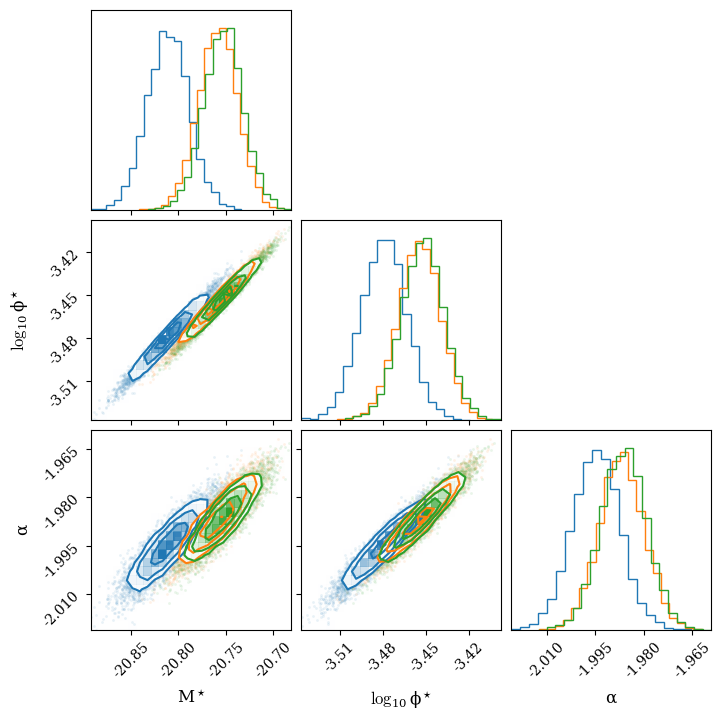

In [13]:
import corner

labels = [r"$M^\star$", r"$\log_{10}\phi^\star$", r"$\alpha$"]

fig = corner.corner(
    results[0],
    labels=labels,
    color="C0",
    label_kwargs={"fontsize": 12}
)

corner.corner(
    results[1],
    fig=fig,
    color="C1"
)

corner.corner(
    results[2],
    fig=fig,
    color="C2"
)

plt.show()

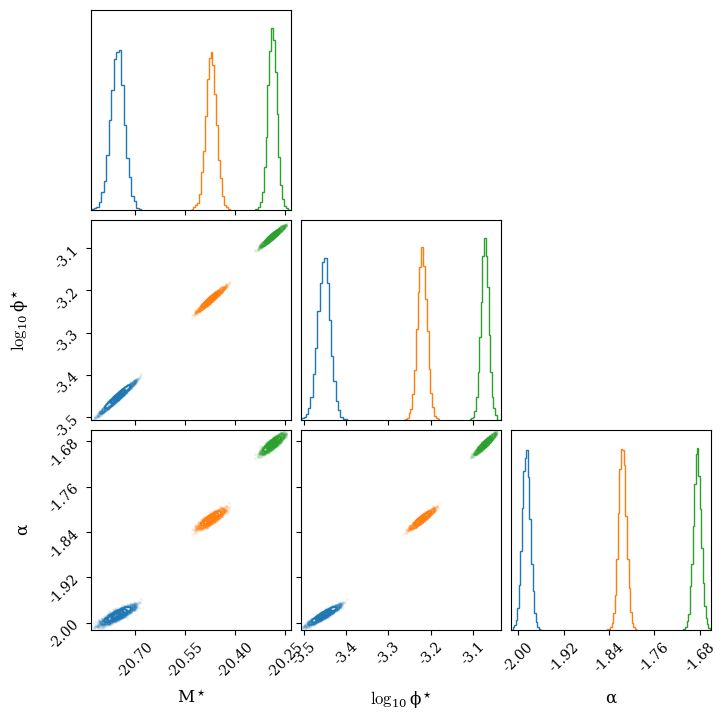

In [14]:
labels = [r"$M^\star$", r"$\log_{10}\phi^\star$", r"$\alpha$"]

fig = corner.corner(
    results[2],
    labels=labels,
    color="C0",
    label_kwargs={"fontsize": 12}
)

corner.corner(
    results[3],
    fig=fig,
    color="C1"
)

corner.corner(
    results[4],
    fig=fig,
    color="C2"
)

plt.show()

#### 5/13:
also try changing bin phase <br>
run different bins multiple times - compute jitter to see which moves around the most <br>
track how the center point moves around <br>
also compute jitter for bin phase <br>


make corner plots <br>
explore posterior <br>
chains - show path each walker took <br>
likelihood function - chi^2, unbinned - explore param space and draw sample each time <br>
take binned chi^2 - current bins, large bins, adaptive bins - each bin has same # of objects <br>
- fit them the same way - see how posterior changes <br>
- adaptive phi - will need to divide by bin width of each bin, poisson err constant <br>

plot uvlf as points - x
number of walkers should be double number of free params <br>
David Hogg paper on statistics <br>
Forman-Mackey - author of emcee <br>
plot in log on y axis - change plot_sample to be linear <br>
emcee can plot autocorrelation between runs - plot autocorrelation vs lag <br>
trace plot <br>
take all final draws and overplot on input schechter <br>
errorbar for model - shouldn't be schechter function shaped <br>
plot peak and median of posteriors - will be same if gaussian, not if skewed - errorbar is on the median <br>
if there is skew - best fit != median and only median has errors <br>
Weaver+23 mass function paper <br>
residual plot - collapse into 1D distribution and run normality checks <br>
the lady tasting tea - development of statistics - non parametric <br>

You must install the tqdm library to use progress indicators with emcee


True expected number in volume: 205358.9
number of galaxies drawn: 205358
Acceptance fraction: 0.128
Fit results:
M* = -20.7193772103345
phi* = 0.00037319142509508466
alpha = -1.9766657945612223


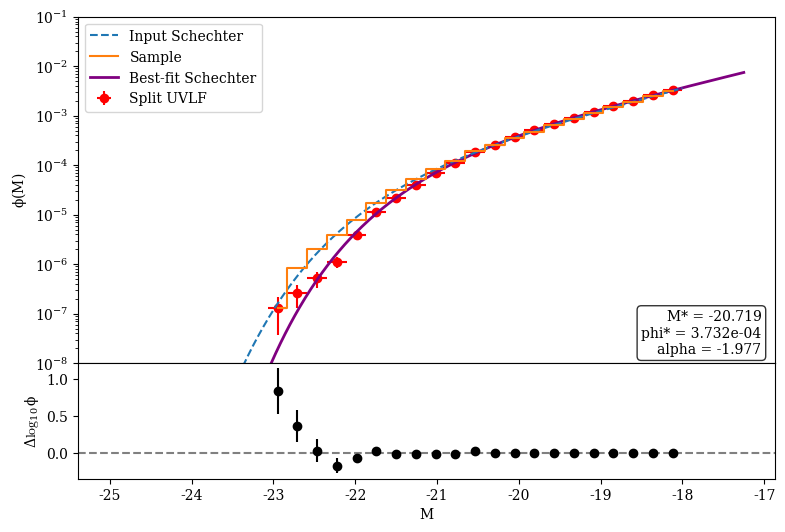

In [22]:
# Schechter params (input / true)
schechter_params_true = (-21.15, 0.19e-3, -2.06)

# Magnitude range
M_faint = -18 
M_bright = -25 
volume = 400**3

bins = np.linspace(M_bright, M_faint, 30)
bin_widths = np.diff(bins)

# Sample once
M_samples = sample_from_schechter(
    *schechter_params_true,
    M_faint=M_faint,
    M_bright=M_bright,
    volume=volume,
    plot_results=False
)

fig, (ax_main, ax_resid) = plt.subplots(
    2, 1, figsize=(9,6), sharex=True,
    gridspec_kw={
        'height_ratios': [3,1],
        'hspace': 0
    }
)

plot_sample(
    M_samples, 
    *schechter_params_true, 
    M_bright, M_faint, 
    volume, 
    plot_input=True,
    ax=ax_main
    )

# Apply splitting once (this is your "observed" data)
M_split = apply_splitting(M_samples, M0=-21.5, k=1.0)

# Run Emcee
sampler, samples = fit_schechter_from_binning(M_split, 
                                              bins, 
                                              volume, 
                                              ax_main=ax_main, 
                                              ax_resid=ax_resid
                                              )

## Posterior of Run

### Signs of a Good Run:
- walkers rapidly move toward the same region
- after burn-in, they overlap and interweave
- no long-term drift upward/downward
- chains resemble “fuzzy caterpillars”
- all walkers explore similar parameter ranges

Autocorrelation Time: [42.57140316 41.74900472 38.58765464]


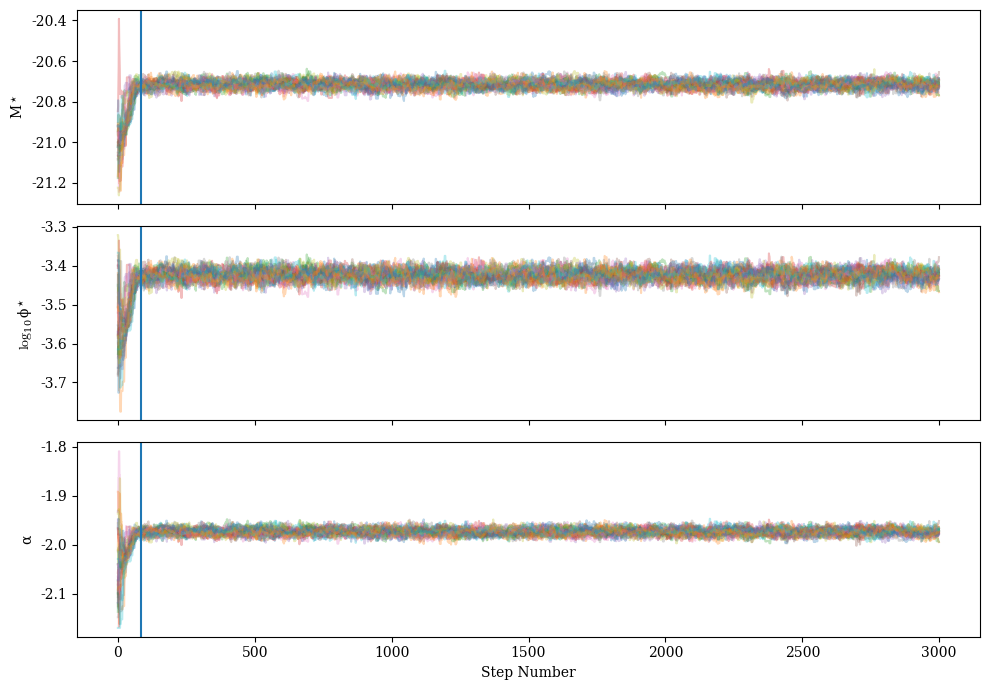

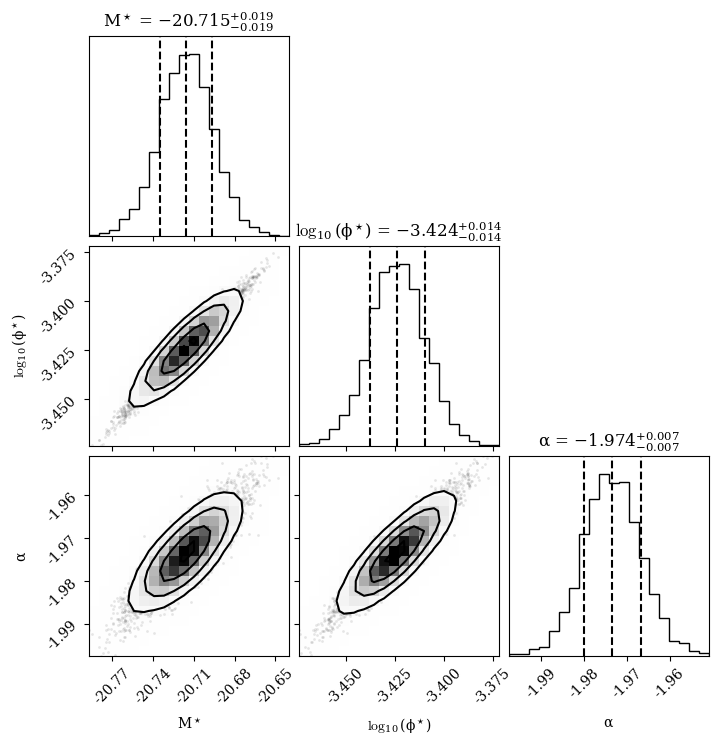

In [16]:
# --------------------------
# PLOT CHAINS (PARAM VS STEP)
# --------------------------
tau = sampler.get_autocorr_time()

print("Autocorrelation Time:", tau)

burnin = int(2 * np.max(tau))
thin = int(0.5 * np.min(tau))

chain = sampler.get_chain()     # no discarding or thinning

samples = sampler.get_chain(    # with discarding and thinning
    discard=burnin,
    thin=thin,
)

fig, axes = plt.subplots(3, figsize=(10,7), sharex=True)

param_labels = [r"$M^\star$", r"$\log_{10}\phi^\star$", r"$\alpha$"]

ndim = 3
nwalkers = 32

for i in range(ndim):
    ax = axes[i]
    
    for walker in range(nwalkers):
        ax.plot(chain[:, walker, i], alpha=0.3)

    # plot burn in
    ax.axvline(burnin)
    
    ax.set_ylabel(param_labels[i])

axes[-1].set_xlabel("Step Number")

plt.tight_layout()
plt.show()

# ------------
# CORNER PLOTS
# ------------
import corner

# labels for parameters
labels = [
    r"$M^\star$",
    r"$\log_{10}(\phi^\star)$",
    r"$\alpha$"
]

# optional: truths = input values
truths = [
    schechter_params_true[0],                  # M*
    np.log10(schechter_params_true[1]),        # log10(phi*)
    schechter_params_true[2]                   # alpha
]

# Fit Parameters
samples = sampler.get_chain(discard=burnin, thin=thin, flat=True)

fig = corner.corner(
    samples,
    labels=labels,
    truths=truths,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    title_kwargs={"fontsize": 12},
    smooth=1.0
)

plt.show()

# Showing "Jitter" of Best-Fit Params based on choice of bin

## Step 1: Generate 1000 datasets, save to drive
Computationally Expensive, already ran once (that is enough)

In [17]:
# n_realizations = 1000

# all_samples = []

# for i in range(n_realizations):

#     M_samples = sample_from_schechter(
#         *schechter_params_true,
#         M_faint=M_faint,
#         M_bright=M_bright,
#         volume=volume,
#         plot_results=False,
#         verbose=False
#     )

#     all_samples.append(M_samples)

# import os

# outfile = os.path.join(code_path, "mock_uvlf_samples.npy")
# np.save(outfile, np.array(all_samples, dtype=object))

# print("Saved", n_realizations, "mock catalogs")

## Step 2: Load in Samples, Run Experiments

In [18]:
import os
outfile = os.path.join(code_path, "mock_uvlf_samples.npy")

all_samples = np.load(
    outfile,
    allow_pickle=True
)

print(type(all_samples))
print(len(all_samples))
print(all_samples.shape)
print(all_samples.dtype)


bins_list = [
    np.linspace(M_bright, M_faint, 10),
    np.linspace(M_bright, M_faint, 20),
    np.linspace(M_bright, M_faint, 30),
    # phase_shifted_bins(M_bright, M_faint, 30, phase=0.25),
    # phase_shifted_bins(M_bright, M_faint, 30, phase=0.5),
]

bin_names = [
    '10 Equal Size Bins',
    '20 Equal Size Bins',
    '30 Equal Size Bins',
    # '30 Bins, Phase=0.25',
    # '30 Bins, Phase=0.50',
]

# Store Experiment Results:
fit_results = {
    name: []
    for name in bin_names
}

for M_samples in all_samples:

    M_split = apply_splitting(
        M_samples,
        M0=-21.5,
        k=1.0
    )

    for name, bins in zip(bin_names, bins_list):

        sampler, samples = fit_schechter_from_binning(
            M_split,
            bins,
            volume,
            plot_fit=False,
            verbose=False
        )

        # store medians only
        median_fit = np.median(samples, axis=0)

        fit_results[name].append(median_fit)

# Convert to Arrays:
for key in fit_results:
    fit_results[key] = np.array(fit_results[key])

You must install the tqdm library to use progress indicators with emcee


<class 'numpy.ndarray'>
1000
(1000, 205358)
object


You must install the tqdm library to use progress indicators with emcee
You must install the tqdm library to use progress indicators with emcee
You must install the tqdm library to use progress indicators with emcee
You must install the tqdm library to use progress indicators with emcee
You must install the tqdm library to use progress indicators with emcee
You must install the tqdm library to use progress indicators with emcee
You must install the tqdm library to use progress indicators with emcee
You must install the tqdm library to use progress indicators with emcee
You must install the tqdm library to use progress indicators with emcee
You must install the tqdm library to use progress indicators with emcee
You must install the tqdm library to use progress indicators with emcee
You must install the tqdm library to use progress indicators with emcee
You must install the tqdm library to use progress indicators with emcee
You must install the tqdm library to use progress indicators wit

## Step 3: Visualize Jitter:

In [19]:
# Debugging:
print(fit_results[bin_names[0]].shape)

print(type(fit_results[bin_names[0]]))
print(len(fit_results[bin_names[0]]))
print(fit_results[bin_names[0]][0])

print(type(fit_results[bin_names[0]][0]))
print(fit_results[bin_names[0]][0].shape)

for name in bin_names:
    print(name, np.shape(fit_results[name]))

(1000, 3)
<class 'numpy.ndarray'>
1000
[-20.79446931  -3.466078    -1.99245213]
<class 'numpy.ndarray'>
(3,)
10 Equal Size Bins (1000, 3)
20 Equal Size Bins (1000, 3)
30 Equal Size Bins (1000, 3)


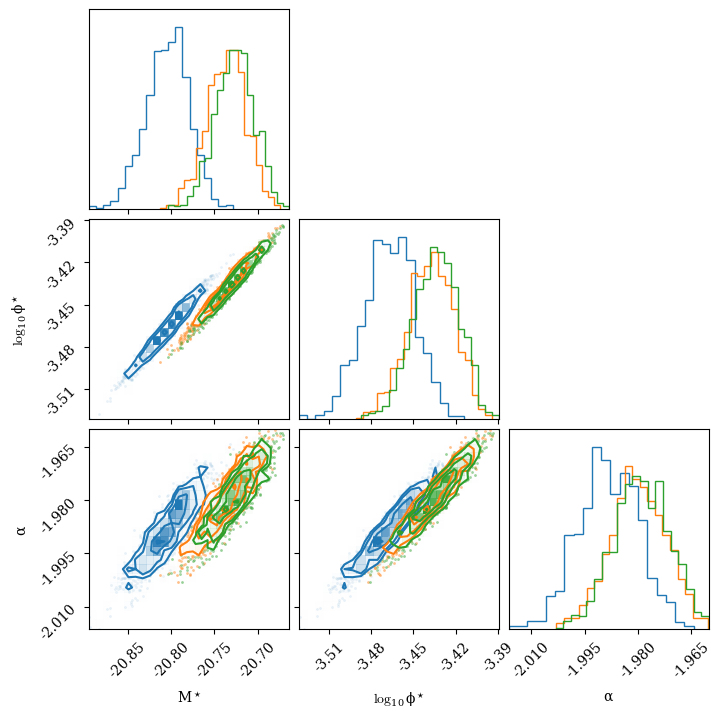

In [20]:
labels = [
    r"$M^\star$",
    r"$\log_{10}\phi^\star$",
    r"$\alpha$"
]

fig = corner.corner(
    fit_results[bin_names[0]],
    labels=labels,
    color="C0"
)

for i, name in enumerate(bin_names[1:]):
    corner.corner(
        fit_results[name],
        labels=labels,
        fig=fig,
        color=f"C{i+1}",
        plot_datapoints=True,
        plot_density=True,
        plot_contours=True,
        data_kwargs={"alpha": 0.5}
    )

plt.show()

# ================================================================================

## Build Forward Model

In [ ]:
def compute_uvlf(M_samples, bins, volume):
    # binning function 
    hist, edges = np.histogram(M_samples, bins=bins)
    phi = hist / volume / np.diff(edges)54
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, phi

def model_uvlf(params, bins, volume, schechter_params, N=10000):
    """
    Forward Model
    """
    M0, k = params
    
    # 1. create sample
    M_samples = sample_from_schechter(*schechter_params,
                                     volume=volume,
                                     M_bright=M_bright,
                                     M_faint=M_faint,
                                     plot_results=False)
    
    # 2. apply splitting
    M_split = apply_splitting(M_samples, M0=M0, k=k)
    
    # 3. compute UVLF
    _, phi_model = compute_uvlf(M_split, bins, volume)
    
    return phi_model

# Define likelihood
def chi2(params, bins, volume, schechter_params, phi_obs, phi_err):
    phi_model = model_uvlf(params, bins, volume, schechter_params)
    # add convolution kernel from astropy - 1-2 d.o.f. 
    # logistic, lorentzian, cauchy, gaussian
    return np.sum(((phi_model - phi_obs) / phi_err)**2)

from scipy.optimize import minimize

# --- Example parameters (z ~ 6.8) ---
phi_star_bouwens = 0.19e-3
M_star_bouwens = -21.15
alpha_bouwens = -2.06

schechter_params = [M_star_bouwens, phi_star_bouwens, alpha_bouwens]

bin_width = 0.25

M_bright = -23.75
M_faint = -20.25
mag_cutoff = -20.1

bins_regular = np.arange(M_bright, M_faint, bin_width)  # magnitude bins width 0.25
bins_M = np.append(bins_regular, mag_cutoff)

print('bins', bins_M)

phi_obs = UVLF_5050['phi']
phi_err = UVLF_5050['phi_err']

result = minimize(chi2,
                  x0=[-21.5, 1.0],   # initial guess
                  args=(bins_M, volume, schechter_params, phi_obs, phi_err),
                  bounds=[(-24, -18), (0.1, 5)])

best_M0, best_k = result.x

SyntaxError: invalid syntax (2931674461.py, line 4)

True expected number in volume: 10384.0
number of galaxies drawn: 10384
Acceptance fraction: 0.173


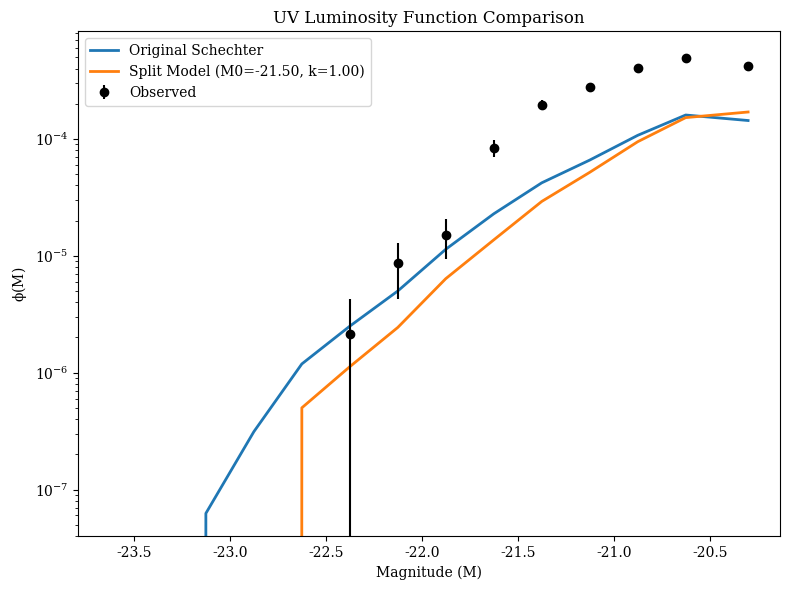

/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_4354/1424156020.py:42: RuntimeWarning: divide by zero encountered in divide
  residuals = (phi_best - phi_obs) / phi_err
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_4354/1424156020.py:42: RuntimeWarning: invalid value encountered in divide
  residuals = (phi_best - phi_obs) / phi_err


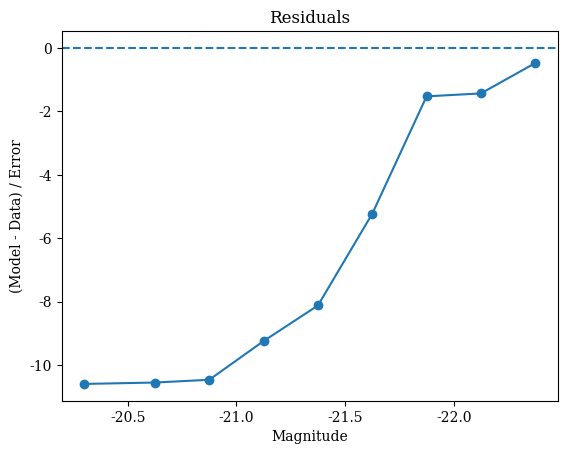

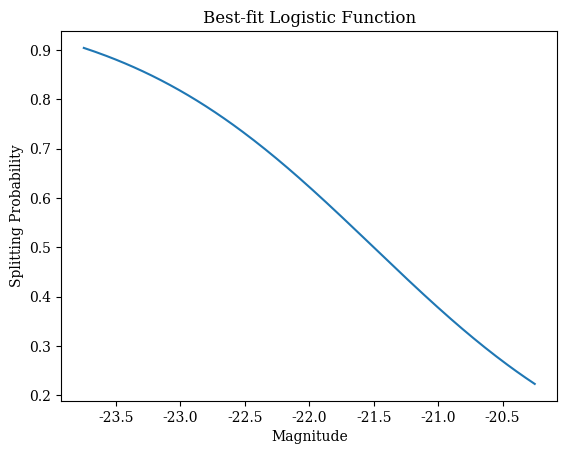

In [ ]:
# --- Best-fit params ---
M0_best, k_best = result.x

# --- 1. Original sample (no splitting) ---
M_samples = sample_from_schechter(*schechter_params,
                                 volume=volume,
                                 M_bright=M_bright,
                                 M_faint=M_faint,
                                 plot_results=False)

centers, phi_original = compute_uvlf(M_samples, bins_M, volume)

# --- 2. Apply best-fit splitting ---
M_split_best = apply_splitting(M_samples, M0=M0_best, k=k_best)

_, phi_best = compute_uvlf(M_split_best, bins_M, volume)

plt.figure(figsize=(8,6))

# Original Schechter
plt.plot(centers, phi_original, label='Original Schechter', lw=2)

# Best-fit split model
plt.plot(centers, phi_best, label=f'Split Model (M0={M0_best:.2f}, k={k_best:.2f})', lw=2)

# Observed data
plt.errorbar(centers, phi_obs, yerr=phi_err,
             fmt='o', color='black', label='Observed')

# Formatting
plt.yscale('log')
plt.xlabel('Magnitude (M)')
plt.ylabel(r'$\phi(M)$')
plt.legend()
# plt.gca().invert_xaxis()  # brighter = left (standard in UVLF)

plt.title('UV Luminosity Function Comparison')
plt.tight_layout()
plt.show()

# --- Plot Residuals ---
residuals = (phi_best - phi_obs) / phi_err

plt.figure()
plt.axhline(0, linestyle='--')
plt.plot(centers, residuals, 'o-')
plt.xlabel('Magnitude')
plt.ylabel('(Model - Data) / Error')
plt.gca().invert_xaxis()
plt.title('Residuals')
plt.show()


# --- Plot Logistic Function ---
M_grid = np.linspace(M_bright, M_faint, 200)
P = logistic(M_grid, M0_best, k_best)

plt.figure()
plt.plot(M_grid, P)
plt.xlabel('Magnitude')
plt.ylabel('Splitting Probability')
# plt.gca().invert_xaxis()
plt.title('Best-fit Logistic Function')
plt.show()

## Using Emcee to get best fit M0 and k

True expected number in volume: 10384.0
number of galaxies drawn: 10384
Acceptance fraction: 0.171


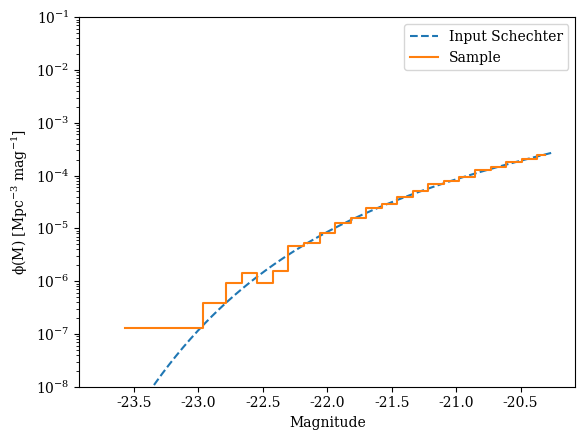

In [ ]:
# Pre-sample ONCE
phi_obs = UVLF_5050['phi']
phi_err = UVLF_5050['phi_err']
phi_err = np.where(phi_err == 0, 1e-10, phi_err)    # non-zero error

phi_star_bouwens = 0.19e-3
M_star_bouwens = -21.15
alpha_bouwens = -2.06

schechter_params = [M_star_bouwens, phi_star_bouwens, alpha_bouwens]

bin_width = 0.25

M_bright = -23.75
M_faint = -20.25
mag_cutoff = -20.1

volume = 400**3

M_samples_fixed = sample_from_schechter(*schechter_params,
                                        volume=volume,
                                        M_bright=M_bright,
                                        M_faint=M_faint,
                                        plot_results=True)

def model_uvlf_fixed(theta, bins, volume, M_samples):
    M0, k = theta
    
    M_split = apply_splitting(M_samples, M0=M0, k=k)
    _, phi_model = compute_uvlf(M_split, bins, volume)
    
    return phi_model

In [ ]:
# --- Define Priors ---
def log_prior(theta):
    M0, k = theta
    
    if -24 < M0 < -18 and 0 < k < 5:
        return 0.0  # flat prior
    return -np.inf

# --- Define Likelihood Function ---
def log_likelihood(theta, bins, volume, M_samples, phi_obs, phi_err):
    phi_model = model_uvlf_fixed(theta, bins, volume, M_samples)
    
    chi2_val = np.sum(((phi_model - phi_obs) / phi_err)**2)
    return -0.5 * chi2_val

# --- Define Posterior ---
def log_probability(theta, bins, volume, schechter_params, phi_obs, phi_err):
    lp = log_prior(theta)
    
    if not np.isfinite(lp):
        return -np.inf
    
    return lp + log_likelihood(theta, bins, volume, schechter_params, phi_obs, phi_err)

In [ ]:
print("volume:", volume)
print("bin widths:", np.diff(bins_M))

print(phi_err)

volume: 64000000
bin widths: [0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.4 ]
[1.00000000e-10 1.00000000e-10 1.00000000e-10 1.00000000e-10
 1.00000000e-10 2.15353529e-06 4.30707057e-06 5.69771880e-06
 1.34488235e-05 2.05434173e-05 2.44594590e-05 2.94491521e-05
 3.27309026e-05 2.38504641e-05]


In [ ]:
import emcee

ndim = 2
nwalkers = 32

# Initialize walkers near your previous best-fit
initial = np.array([best_M0, best_k])
pos = initial + 1e-2 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_probability,
    args=(bins_M, volume, M_samples_fixed, phi_obs, phi_err)
)

sampler.run_mcmc(pos, 3000, progress=True)

You must install the tqdm library to use progress indicators with emcee
/var/folders/k7/1njpygzx1gx7nl6dnq4_mbcm0000gn/T/ipykernel_4354/4104836333.py:19: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp((M - M0) / k))


State([[-2.12747539e+01  5.24127455e-01]
 [-2.09693238e+01  8.01238934e-02]
 [-2.09468529e+01  2.94179086e-02]
 [-2.08970656e+01  4.83873550e-03]
 [-2.11985419e+01  4.93809574e-01]
 [-2.12882403e+01  6.35033769e-01]
 [-2.09242127e+01  2.43510696e-02]
 [-2.09624572e+01  5.23629801e-03]
 [-2.12278379e+01  5.35459761e-01]
 [-2.11710537e+01  4.17207438e-01]
 [-2.08683515e+01  8.06407326e-03]
 [-2.10319967e+01  1.08717183e-01]
 [-2.09222552e+01  9.56227287e-03]
 [-2.09397135e+01  1.78045319e-02]
 [-2.08783862e+01  2.15700046e-02]
 [-2.09439887e+01  3.00216614e-02]
 [-2.11233883e+01  3.76629207e-01]
 [-2.12273272e+01  5.23533343e-01]
 [-2.08960620e+01  1.06981596e-02]
 [-2.10031965e+01  3.49463891e-01]
 [-2.14324147e+01  8.92264832e-01]
 [-2.11267908e+01  3.71405655e-01]
 [-2.09262127e+01  4.89442783e-02]
 [-2.09175992e+01  5.31075059e-03]
 [-2.08470535e+01  4.11687071e-04]
 [-2.09229412e+01  1.47580163e-02]
 [-2.08982341e+01  1.92135442e-03]
 [-2.09715334e+01  5.21434132e-02]
 [-2.08917428e

M0 = -20.97 ± 0.15
k  = 0.04 ± 0.26


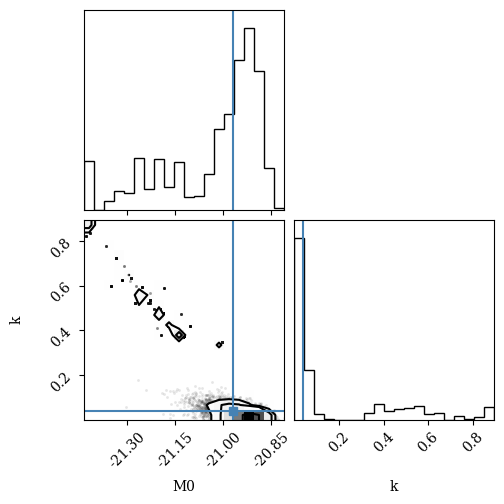

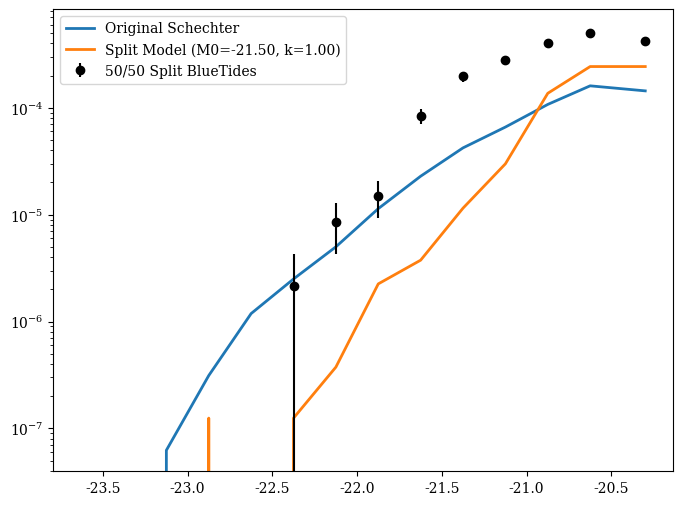

In [ ]:
samples = sampler.get_chain(discard=500, thin=10, flat=True)

M0_mcmc, k_mcmc = np.percentile(samples, [50], axis=0)[0]

M0_err = np.std(samples[:,0])
k_err = np.std(samples[:,1])

print(f"M0 = {M0_mcmc:.2f} ± {M0_err:.2f}")
print(f"k  = {k_mcmc:.2f} ± {k_err:.2f}")

import corner
corner.corner(samples, labels=["M0", "k"], truths=[M0_mcmc, k_mcmc])

plt.figure(figsize=(8,6))

# Original Schechter
centers, phi_original = compute_uvlf(M_samples, bins_M, volume)
plt.plot(centers, phi_original, label='Original Schechter', lw=2)

# Best-fit split model
M_split_best = apply_splitting(M_samples_fixed, M0=M0_mcmc, k=k_mcmc)
centers, phi_best = compute_uvlf(M_split_best, bins_M, volume)

plt.plot(centers, phi_best, label=f'Split Model (M0={M0_best:.2f}, k={k_best:.2f})', lw=2)

# Observed data
plt.errorbar(centers, phi_obs, yerr=phi_err,
             fmt='o', color='black', label='50/50 Split BlueTides')

plt.yscale('log')
plt.legend()
